In [1]:
import sys
import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from math import*
import pandas as pd

from rkhs_glm_scaled import RKHSGLM_Scaled, sigmoid

from pseudo_label_experiment_general import FAMILIES, make_data, mean, KGLM_covariate_shift, a_logpartition, run_experiment

import os
import sys

In [ ]:
def f_star(x, fcn): # get true regression function
    if fcn == 'C':
        return np.cos(x * 2 * np.pi) - 1
    if fcn == 'S':
        return np.sin(x * 2 * np.pi)
    if fcn == 'V':
        return np.abs(x - 1/2) - 1/2
    if fcn == 'W':
        f_1 = np.clip( np.abs(4 * x - 1), 0, 1)
        f_2 = np.clip( np.abs(4 * x - 3), 0, 1)
        return f_1 + f_2 - 2
    if fcn == 'x':
        return x * np.sin(4 * np.pi * x)
    if fcn == 'lin':
        return 4 * (x - 0.5)
    if fcn == 'quad':
        return 16*(x-1/2)**2 - 2
    if fcn == 'tan':
        return (np.tan(np.pi*(x-1/2)))**2 - 2
    if fcn == 'abs':
        return 8*np.abs(x-1/2) - 2


#fcn = lambda x : f_star(x, 'abs')

def fcn(x):
    return 1.5*np.cos(x * 2 * np.pi)

In [ ]:
beta = 2 # ratio parameter in the grid of lambdas
seed = 100 # random seed
rng = np.random.default_rng(seed)


n = 4000 # number of source samples
n_0 = n # number of unlabeled target samples
#B = 22 # parameter of distribution shift
B = n ** (0.4)
fcn = lambda x: 1.5*np.cos(2*np.pi*x)
#fcn = lambda x: 6*np.abs(0.5- x) - 1.5

test = KGLM_covariate_shift(n, n_0, B, fcn=fcn, family='logistic', kernel='sobolev_intercept', seed=seed)
test.fit(beta = beta)

Target excess risks: estimated by Monte Carlo method, report means and standard errors
Naive: 0.04345423329335496 (0.0007002170840524376)
Pseudo-Labeling: 0.03612343729772449 (0.0007227330152409561)
Oracle: 0.03278680842962889 (0.0006870784587961103)

Selected lambdas: 
Naive: 0.0004
Pseudo-Labeling: 5e-05
Oracle: 0.0001


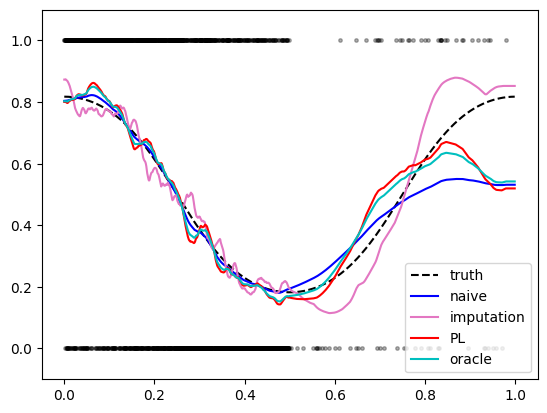

In [ ]:
# Visualization and evaluation of selected models
# True function: black dashed line
# Source data: gray dots
# Naive method (hold-out validation using source data): blue
# Imputation model (undersmoothed): pink
# New method (hold-out validation with pseudo-labels): red
# Oracle method (validation with noiseless true labels): cyan


#####################
# visualization
X_new = np.arange(0, 1, 0.001) # grid
test.predict_final(X_new)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-0.1, 1.1]

plt.ylim(ylim)
plt.xlim(xlim)
plt.plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label = 'truth')
plt.plot(X_new, test.mean_new_naive, 'b-', label = 'naive')
plt.plot(X_new, test.mean_new_tilde, color = 'tab:pink', label = 'imputation')
plt.plot(X_new, test.mean_new_pseudo, 'r-', label = 'PL')
plt.plot(X_new, test.mean_new_real, 'c-', label = 'oracle')

plt.legend(loc = 'lower right')
#ax.set_aspect( (xlim[1] - xlim[0]) / (ylim[1] - ylim[0]) )


#####################
# evaluation
N_test = 10000
test.evaluate_final(N_test = N_test, seed = seed)
print('Target excess risks: estimated by Monte Carlo method, report means and standard errors')
print('Naive: {} ({})'.format(test.err_naive, test.err_naive_ste))
print('Pseudo-Labeling: {} ({})'.format(test.err_pseudo, test.err_pseudo_ste))
print('Oracle: {} ({})'.format(test.err_real, test.err_real_ste))


# report selected lambdas
lbds = [test.lbd_naive, test.lbd_pseudo, test.lbd_real]
print('')
print('Selected lambdas: ')
print('Naive: {}'.format(lbds[0]))
print('Pseudo-Labeling: {}'.format(lbds[1]))
print('Oracle: {}'.format(lbds[2]))

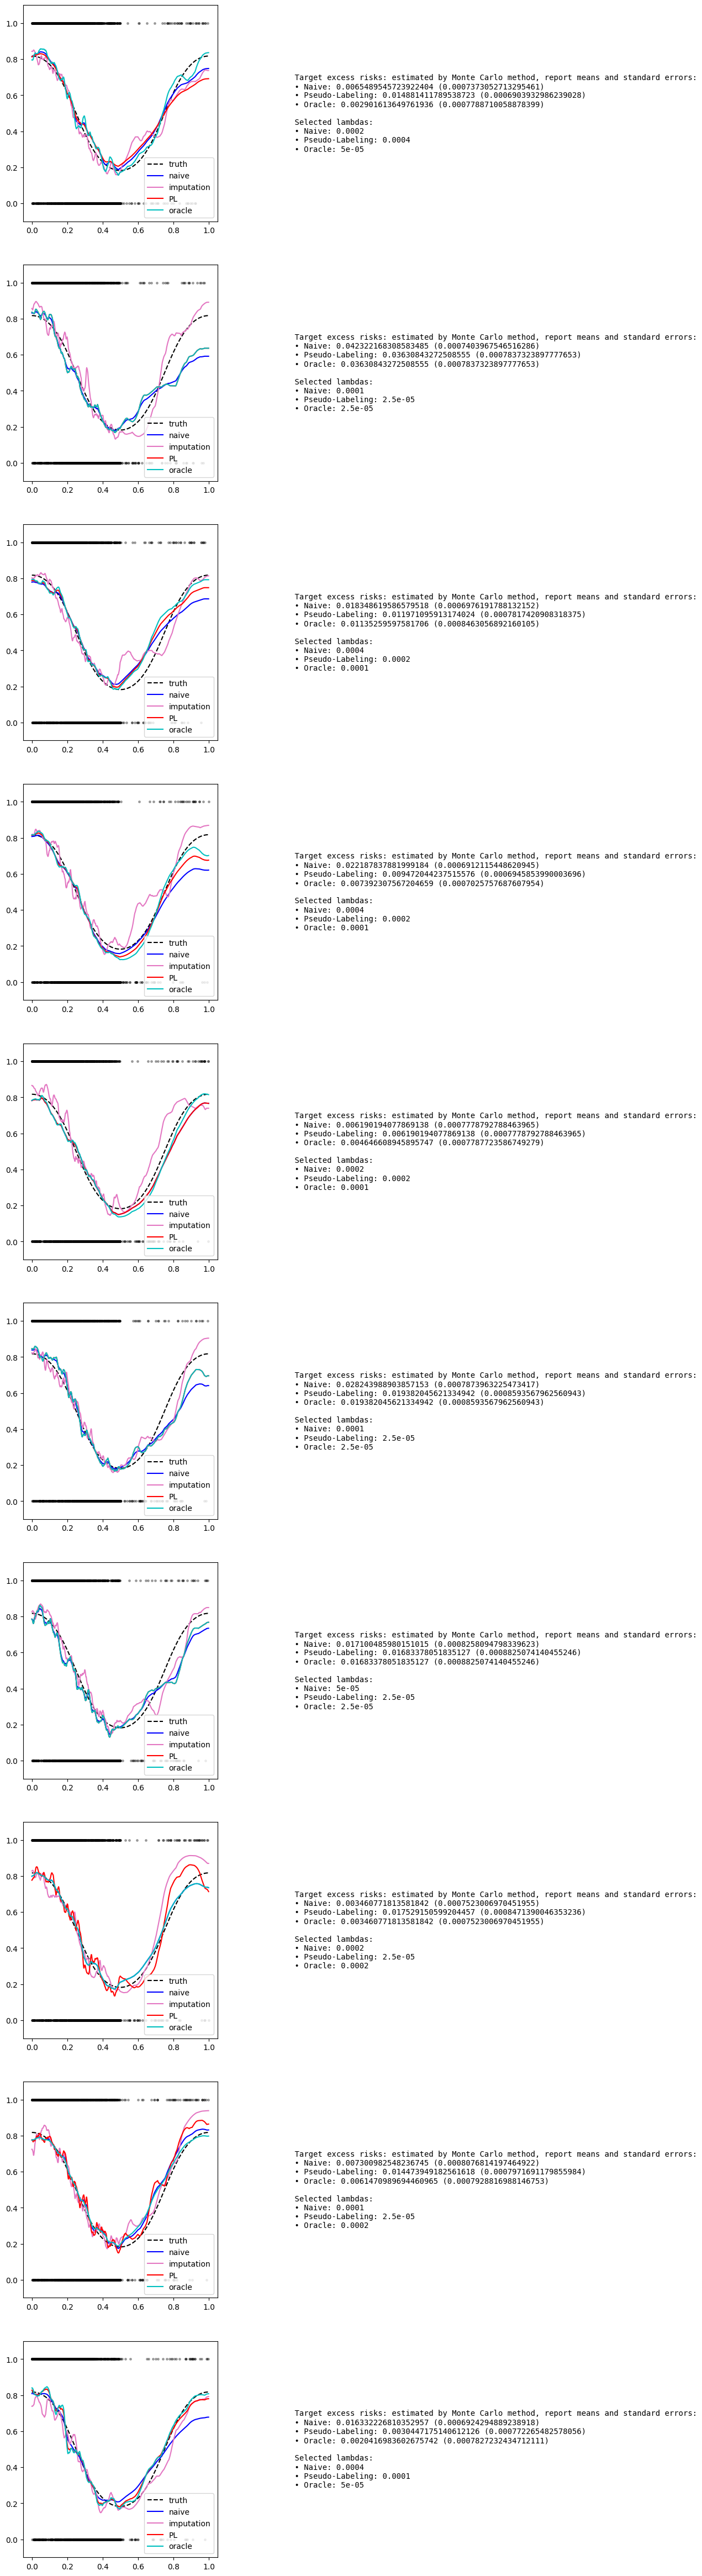

In [ ]:
seed_list = list(range(20, 30))
list_model = []
restot = []

# small, medium, and large penalty parameters
list_idx_candidates = [2, 4, 6]
penalty_size = {0: 'small', 1: 'medium', 2: 'large'}
N_test = 10000 # number of new testing samples for evaluation
xlim = [-0.05, 1.05]
ylim = [-0.1, 1.1]

fig, axs = plt.subplots(ncols=2, nrows=10, figsize=(10, 60))

for k, seed in enumerate(seed_list):
    test = KGLM_covariate_shift(n=n, n_0=n, B=B, fcn=fcn, family='logistic', kernel='sobolev_intercept', seed=seed)
    test.fit(beta = beta)
    list_model.append(test)

    X_new = np.arange(0, 1, 0.001) # grid
    test.predict_final(X_new)

    axs[k, 0].set_ylim(ylim)
    axs[k, 0].set_xlim(xlim)
    axs[k, 0].plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
    axs[k, 0].plot(X_new, test.mean_new_true, 'k--', label = 'truth')
    axs[k, 0].plot(X_new, test.mean_new_naive, 'b-', label = 'naive')
    axs[k, 0].plot(X_new, test.mean_new_tilde, color = 'tab:pink', label = 'imputation')
    axs[k, 0].plot(X_new, test.mean_new_pseudo, 'r-', label = 'PL')
    axs[k, 0].plot(X_new, test.mean_new_real, 'c-', label = 'oracle')



    axs[k, 0].legend(loc = 'lower right')

    #####################
    # evaluation
    test.evaluate_final(N_test = N_test, seed = seed)
    axs[k, 1].axis('off')  # Turn off axis

    info_text = f"""
    Target excess risks: estimated by Monte Carlo method, report means and standard errors:
    • Naive: {test.err_naive} ({test.err_naive_ste})
    • Pseudo-Labeling: {test.err_pseudo} ({test.err_pseudo_ste})
    • Oracle: {test.err_real} ({test.err_real_ste})

    Selected lambdas:
    • Naive: {test.lbd_naive}
    • Pseudo-Labeling: {test.lbd_pseudo}
    • Oracle: {test.lbd_real}
    """

    res = np.array([test.err_naive, test.err_pseudo, test.err_real])
    restot.append(res)

    axs[k, 1].text(0.1, 0.5, info_text,
                    transform=axs[k, 1].transAxes,
                    fontsize=10, verticalalignment='center',
                    family='monospace')


restot = np.array(restot)
#np.savetxt('results_general.csv', restot, delimiter=',')

In [ ]:
idx_list = np.arange(1, 11)

n_list = [2000, 4000, 8000, 16000, 32000]

for n in n_list:
    for idx in idx_list:
        S = 10
        seed_list = np.array(range(1, S + 1)) * 100000 # random seeds
        for i in range(S):
            seed_list[i] = seed_list[i] + (idx - 1) * 1000

        res = run_experiment([n], seed_list, family='gaussian', fcn=fcn, kernel='sobolev')
        fp = os.path.join(outdir, f"{n}_{idx}.txt")
        np.savetxt(fp, res[0])
        print('n {} idx {} finished'.format(n, idx))

    print('sample size {} finished'.format(n))

n 2000 idx 1 finished
n 2000 idx 2 finished
n 2000 idx 3 finished
n 2000 idx 4 finished
n 2000 idx 5 finished
n 2000 idx 6 finished
n 2000 idx 7 finished
n 2000 idx 8 finished
n 2000 idx 9 finished
n 2000 idx 10 finished
sample size 2000 finished
n 4000 idx 1 finished
n 4000 idx 2 finished
n 4000 idx 3 finished
n 4000 idx 4 finished
n 4000 idx 5 finished
n 4000 idx 6 finished
n 4000 idx 7 finished
n 4000 idx 8 finished
n 4000 idx 9 finished
n 4000 idx 10 finished
sample size 4000 finished
n 8000 idx 1 finished
n 8000 idx 2 finished
n 8000 idx 3 finished
n 8000 idx 4 finished
n 8000 idx 5 finished
n 8000 idx 6 finished
n 8000 idx 7 finished
n 8000 idx 8 finished
n 8000 idx 9 finished
n 8000 idx 10 finished
sample size 8000 finished
n 16000 idx 1 finished
n 16000 idx 2 finished
n 16000 idx 3 finished
n 16000 idx 4 finished
n 16000 idx 5 finished
n 16000 idx 6 finished
n 16000 idx 7 finished
n 16000 idx 8 finished
n 16000 idx 9 finished
n 16000 idx 10 finished
sample size 16000 finished
